In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from sklearn.datasets import make_blobs
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [3]:
RANDOM_STATE = 42

In [4]:
custom_colors = ["#00528d", "#d36900"]

In [5]:
def gini_score(y_test, y_proba):
    auc = roc_auc_score(y_test, y_proba[:, 1])
    return 2 * auc - 1

In [6]:
X, y =  make_blobs(
    n_samples=1000,
    # n_features=2, по умолчанию задается 2 признака, можно не писать
    centers=2,
    cluster_std=3.8,
    center_box=(-6.0, 6.0),
    random_state=RANDOM_STATE
)

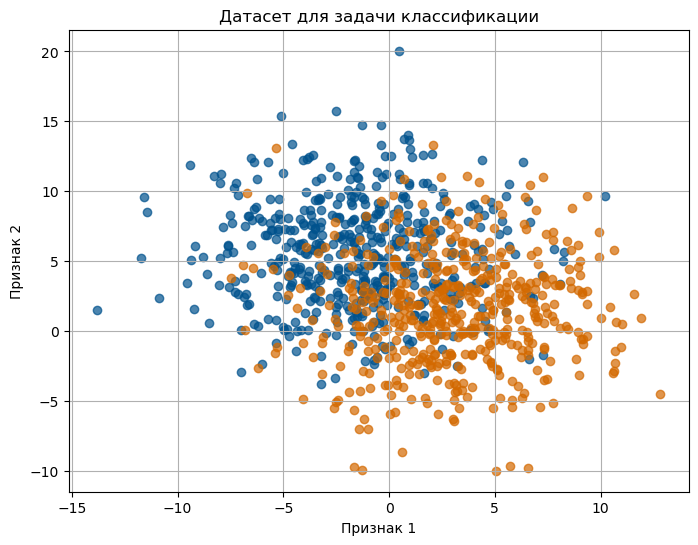

In [7]:
plt.figure(figsize=(8, 6))    

for i in np.unique(y):
    idx = (y == i)
    plt.scatter(X[idx, 0], X[idx, 1], c=custom_colors[i], label=f'Класс {i}', alpha=0.7)
    
plt.title("Датасет для задачи классификации")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.grid(True)
plt.show()
plt.close()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
model_configs = {
        "Logistic Regression": {
            "model": LogisticRegression(random_state=RANDOM_STATE),
            "params": {'C': [0.1, 1, 10]}
        },
        "SVM": {
            "model": SVC(probability=True, random_state=RANDOM_STATE),
            "params": {'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1]}
        },
        "Decision Tree": {
            "model": DecisionTreeClassifier(random_state=RANDOM_STATE),
            "params": {'max_depth': [5, 10, 20], 'min_samples_split': [2, 5, 10]}
        },
        "Random Forest": {
            "model": RandomForestClassifier(random_state=RANDOM_STATE),
            "params": {'n_estimators': [10, 50, 100], 'max_depth': [5, 10, 20]}
        }
    }

In [11]:
results = []
for name, config in model_configs.items():
    grid = GridSearchCV(config["model"], config["params"], cv=5, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    
    y_proba = grid.predict_proba(X_test_scaled)
    gini = gini_score(y_test, y_proba)

    results.append({
        "Модель": name,
        "Коэффициент Джини": round(gini, 4),
        "Лучшие параметры": grid.best_params_
    })
    
pd.DataFrame(results).sort_values(by="Коэффициент Джини", ascending=False)

,Модель,Коэффициент Джини,Лучшие параметры
0,Logistic Regression,0.7857,{'C': 0.1}
1,SVM,0.7833,"{'C': 0.1, 'gamma': 0.01}"
3,Random Forest,0.7543,"{'max_depth': 5, 'n_estimators': 10}"
2,Decision Tree,0.7192,"{'max_depth': 5, 'min_samples_split': 10}"
